## District-Level Millet Yield Forecasting in India using Ensemble ML and Explainable AI

## Project Overview

This project builds a district-level Millet yield forecasting system for India, motivated by India's ongoing millet revolution and the need for data-driven agricultural planning at the district level.

Using 30 years of ICRISAT crop data across Indian districts, combined with kharif season rainfall sourced from the NASA POWER API, I wanted to develop and compare machine learning models to predict annual millet yield.To bring a public policy and governance perspective, SHAP explainability is applied to interpret model predictions and identify the key drivers of yield variation across districts.

## Importing the required Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

!pip install geopy --quiet

from geopy.geocoders import Nominatim
import time
import requests

import joblib


## Loading the Dataset 

**Yield Dataset from ICRISAT Database:**

The ICRISAT District Level Database is loaded directly from Kaggle's input directory. 
This dataset contains district-wise crop production statistics across 20 Indian states 
from 1990 to 2019, covering area, production, and yield for multiple crops including 
all three major millets — Kharif Sorghum (Jowar), Pearl Millet (Bajra), and Finger 
Millet (Ragi).

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ashmirojlipatra/icrisat/ICRISAT-District Level Data (1).csv')
print(df.columns.tolist())
print(df.shape)
print(df.head(3))

['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'KHARIF SORGHUM AREA (1000 ha)', 'KHARIF SORGHUM PRODUCTION (1000 tons)', 'KHARIF SORGHUM YIELD (Kg per ha)', 'RABI SORGHUM AREA (1000 ha)', 'RABI SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM YIELD (Kg per ha)', 'PEARL MILLET AREA (1000 ha)', 'PEARL MILLET PRODUCTION (1000 tons)', 'PEARL MILLET YIELD (Kg per ha)', 'FINGER MILLET AREA (1000 ha)', 'FINGER MILLET PRODUCTION (1000 tons)', 'FINGER MILLET YIELD (Kg per ha)']
(18060, 17)
   Dist Code  Year  State Code    State Name Dist Name  \
0          1  1990          14  Chhattisgarh      Durg   
1          1  1991          14  Chhattisgarh      Durg   
2          1  1992          14  Chhattisgarh      Durg   

   KHARIF SORGHUM AREA (1000 ha)  KHARIF SORGHUM PRODUCTION (1000 tons)  \
0                            0.5                                    0.4   
1                            2.3                                    1.8   
2                            1.0          

 **Rainfall Dataset from NASA POWER API:**

District-level coordinates were obtained by geocoding 363 district names using the Nominatim geocoder (OpenStreetMap),to enrich the yield data with weather information. 
43 districts failed due to alternate or historical spellings in the ICRISAT dataset 
and were excluded, leaving 334 geocoded districts.

Kharif season rainfall (June–September) for each district was then pulled from the 
NASA POWER API (PRECTOTCORR parameter, monthly resolution) covering 1990–2019. 
The geocoding and API functions used to generate these files are preserved below 
as reference. Pre-generated files are loaded directly to avoid repeated API calls.

In [3]:
# --- Geocoding function (used to generate district_coords.csv) ---
# geolocator = Nominatim(user_agent="millet_project")
# def get_coords(dist_name, state_name):
#     try:
#         location = geolocator.geocode(f"{dist_name}, {state_name}, India", timeout=10)
#         if location:
#             return location.latitude, location.longitude
#         return None, None
#     except:
#         return None, None

# --- NASA POWER function (used to generate rainfall_data.csv) ---
# def get_nasa_rainfall(lat, lon, start_year=1990, end_year=2019):
#     url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
#     params = {"parameters": "PRECTOTCORR", "community": "AG",
#               "longitude": lon, "latitude": lat,
#               "start": start_year, "end": end_year, "format": "JSON"}
#     try:
#         r = requests.get(url, params=params, timeout=30)
#         return r.json()['properties']['parameter']['PRECTOTCORR']
#     except:
#         return None

In [4]:
# Load pre-generated files
all_districts = pd.read_csv('/kaggle/input/datasets/ashmirojlipatra/rainfall-data/district_coords.csv')
rainfall_df   = pd.read_csv('/kaggle/input/datasets/ashmirojlipatra/rainfall-data/rainfall_data.csv')
print("Districts loaded:", all_districts.shape)
print("Rainfall loaded:", rainfall_df.shape)

Districts loaded: (457, 5)
Rainfall loaded: (12420, 10)


## Cleaning the Dataset 

In [5]:
df.replace(-1, np.nan, inplace=True)  # to deal with the missing values here and there 
print("Missing values per column:")
print(df.isnull().sum())

print("\nYear range:", df['Year'].min(), "to", df['Year'].max()) # to obtain the timeline that is being dealt with in this project

print("Unique districts:", df['Dist Name'].nunique())  # to identify uniques rows so as to make the cleaning easier 
print("Unique states:", df['State Name'].nunique())

print("\nRows with Pearl Millet yield > 0:", (df['PEARL MILLET YIELD (Kg per ha)'] > 0).sum())  # to decide on to specific millet category
print("Rows with Kharif Sorghum yield > 0:", (df['KHARIF SORGHUM YIELD (Kg per ha)'] > 0).sum())
print("Rows with Finger Millet yield > 0:", (df['FINGER MILLET YIELD (Kg per ha)'] > 0).sum())

Missing values per column:
Dist Code                                   0
Year                                        0
State Code                                  0
State Name                                  0
Dist Name                                   0
KHARIF SORGHUM AREA (1000 ha)            4240
KHARIF SORGHUM PRODUCTION (1000 tons)    4311
KHARIF SORGHUM YIELD (Kg per ha)         4309
RABI SORGHUM AREA (1000 ha)              4825
RABI SORGHUM PRODUCTION (1000 tons)      4155
RABI SORGHUM YIELD (Kg per ha)           4109
PEARL MILLET AREA (1000 ha)              4064
PEARL MILLET PRODUCTION (1000 tons)      4062
PEARL MILLET YIELD (Kg per ha)           4061
FINGER MILLET AREA (1000 ha)             5313
FINGER MILLET PRODUCTION (1000 tons)     5376
FINGER MILLET YIELD (Kg per ha)          5336
dtype: int64

Year range: 1990 to 2019
Unique districts: 596
Unique states: 20

Rows with Pearl Millet yield > 0: 8038
Rows with Kharif Sorghum yield > 0: 8314
Rows with Finger Millet yield >

After analysing the yield values for each millet category, bajra(Pearl Millet) is chosen.
Because eventhough jowar has slightly more rows but bajra has the stronger policy story. It is the flagship crop of India's millet revolution and is grown across Rajasthan, Gujarat, Haryana, UP (major belt).

In [6]:
millet_cols = [
    'Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name',
    'PEARL MILLET AREA (1000 ha)',
    'PEARL MILLET PRODUCTION (1000 tons)',
    'PEARL MILLET YIELD (Kg per ha)'
]

df_millet = df[millet_cols].copy()

df_millet.columns = [
    'dist_code', 'year', 'state_code', 'state_name', 'dist_name',
    'area', 'production', 'yield_kg_ha'
]

df_millet = df_millet[df_millet['yield_kg_ha'] > 0]  # Droping the districts that genuinely doesn't grow bajra OR data missing)
df_millet = df_millet.dropna(subset=['yield_kg_ha'])


print("Shape after cleaning:", df_millet.shape)   # final data after cleaning 
print("\nTop states by number of records:")
print(df_millet['state_name'].value_counts().head(10))
print("\nYear range:", df_millet['year'].min(), "to", df_millet['year'].max())
print("\nSample:")
print(df_millet.head())

Shape after cleaning: (8038, 8)

Top states by number of records:
state_name
Uttar Pradesh     1823
Rajasthan          939
Tamil Nadu         705
Madhya Pradesh     705
Gujarat            645
Maharashtra        641
Haryana            502
Karnataka          461
Andhra Pradesh     327
Orissa             296
Name: count, dtype: int64

Year range: 1990 to 2019

Sample:
    dist_code  year  state_code    state_name dist_name  area  production  \
10          1  2000          14  Chhattisgarh      Durg  0.02        0.01   
20          1  2010          14  Chhattisgarh      Durg  0.33        0.49   
27          1  2017          14  Chhattisgarh      Durg  0.02        0.01   
29          1  2019          14  Chhattisgarh      Durg  0.00        0.00   
61          3  1991          14  Chhattisgarh    Raipur  0.02        0.02   

    yield_kg_ha  
10        500.0  
20       1485.0  
27        333.0  
29       1000.0  
61       1000.0  


In [7]:
districts = df_millet[['dist_name', 'state_name', 'dist_code']].drop_duplicates()
print("Number of districts:", len(districts))
print(districts.head(10))

Number of districts: 457
       dist_name      state_name  dist_code
10          Durg    Chhattisgarh          1
61        Raipur    Chhattisgarh          3
111     Bilaspur    Chhattisgarh          4
120      Raigarh    Chhattisgarh          5
150      Surguja    Chhattisgarh          6
180     Jabalpur  Madhya Pradesh          7
226     Balaghat  Madhya Pradesh          8
240   Chhindwara  Madhya Pradesh          9
270  Narsinghpur  Madhya Pradesh         10
300        Seoni  Madhya Pradesh         11


In [8]:
df_millet = df_millet[~((df_millet['area'] == 0) & (df_millet['yield_kg_ha'] > 0))]  # dropping the abnormal data 
df_millet = df_millet[~((df_millet['production'] == 0) & (df_millet['yield_kg_ha'] > 0))]

print("Final shape:", df_millet.shape)

print("\nYield stats:")
print(df_millet['yield_kg_ha'].describe())
print("\nNulls remaining:")
print(df_millet.isnull().sum())

df_millet.to_csv('bajra_clean.csv', index=False)
print("\nSaved.")

Final shape: (7926, 8)

Yield stats:
count    7926.000000
mean     1144.697566
std       654.065952
min         1.000000
25%       635.355000
50%      1000.000000
75%      1504.000000
max      4810.000000
Name: yield_kg_ha, dtype: float64

Nulls remaining:
dist_code      0
year           0
state_code     0
state_name     0
dist_name      0
area           0
production     0
yield_kg_ha    0
dtype: int64

Saved.


## Exploratory Data Analysis (EDA):

Before modelling, the cleaned Pearl Millet dataset is explored visually to understand 
yield trends over time, regional variation across states, and the distribution of yield 
values across districts.

Four key visualisations are produced:
- National average yield trend from 1990 to 2019
- Average yield by state — identifying high and low performing regions
- Distribution of yield values across all district-year observations
- Yield trends over time for the top 5 states by record count

These plots help in making appropriate feature engineering decisions.

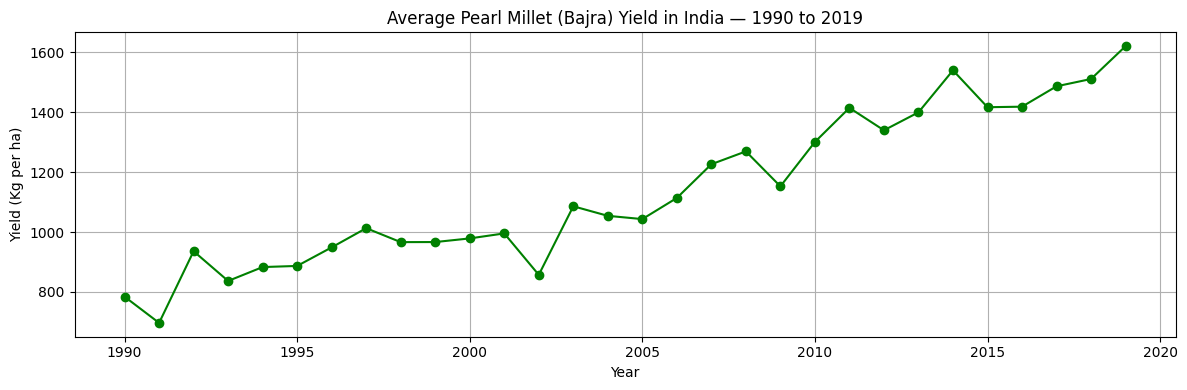

/tmp/ipykernel_16/281779738.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg.values, y=state_avg.index, palette='Greens_r')


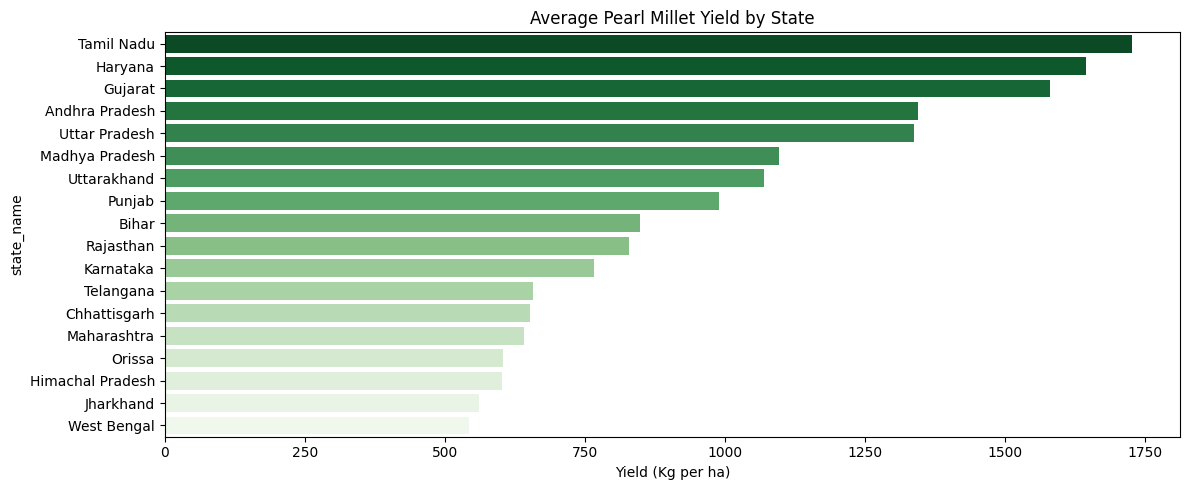

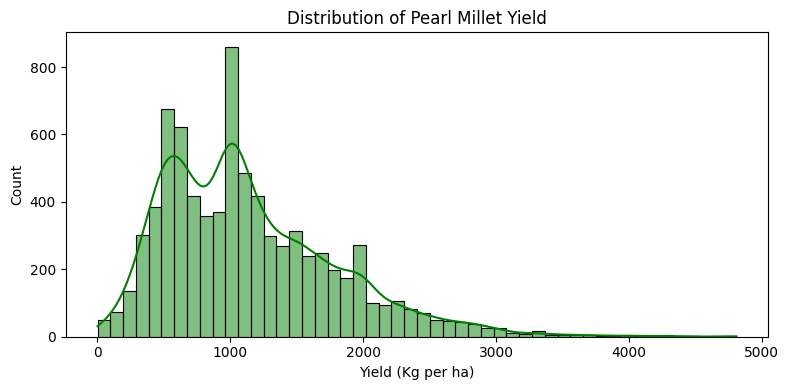

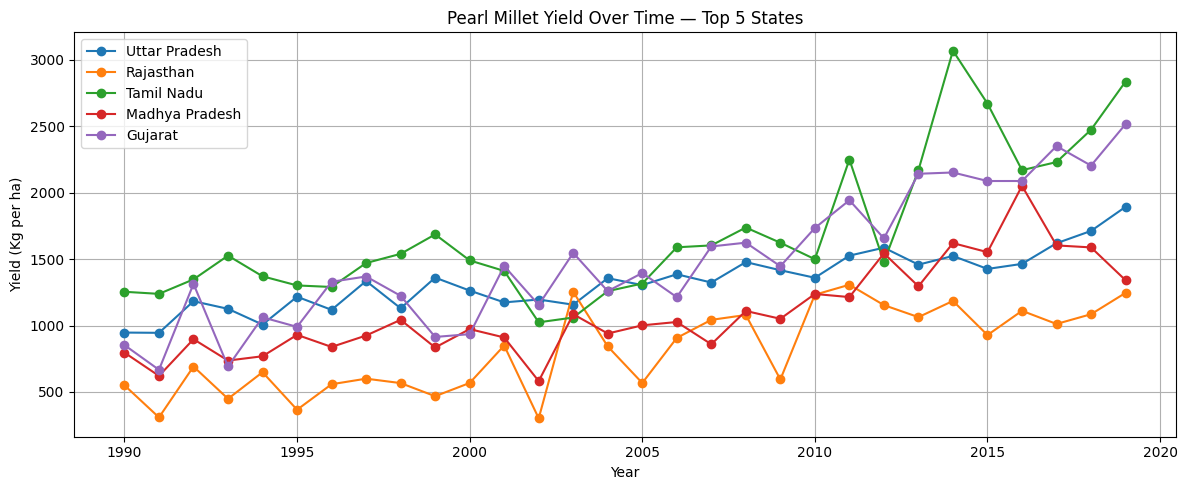

In [9]:
# National average yield trend from 1990 to 2019
yearly_avg = df_millet.groupby('year')['yield_kg_ha'].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(yearly_avg['year'], yearly_avg['yield_kg_ha'], marker='o', color='green')
plt.title('Average Pearl Millet (Bajra) Yield in India — 1990 to 2019')
plt.xlabel('Year')
plt.ylabel('Yield (Kg per ha)')
plt.grid(True)
plt.tight_layout()
plt.savefig('yield_trend.png')
plt.show()

# Average yield by state — identifying high and low performing regions
state_avg = df_millet.groupby('state_name')['yield_kg_ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=state_avg.values, y=state_avg.index, palette='Greens_r')
plt.title('Average Pearl Millet Yield by State')
plt.xlabel('Yield (Kg per ha)')
plt.tight_layout()
plt.savefig('yield_by_state.png')
plt.show()

# Distribution of yield values across all district-year observations
plt.figure(figsize=(8, 4))
sns.histplot(df_millet['yield_kg_ha'], bins=50, color='green', kde=True)
plt.title('Distribution of Pearl Millet Yield')
plt.xlabel('Yield (Kg per ha)')
plt.tight_layout()
plt.savefig('yield_distribution.png')
plt.show()

# Yield trends over time for the top 5 states by record count
top_states = df_millet['state_name'].value_counts().head(5).index
df_top = df_millet[df_millet['state_name'].isin(top_states)]
state_year = df_top.groupby(['year', 'state_name'])['yield_kg_ha'].mean().reset_index()

plt.figure(figsize=(12, 5))
for state in top_states:
    data = state_year[state_year['state_name'] == state]
    plt.plot(data['year'], data['yield_kg_ha'], marker='o', label=state)
plt.title('Pearl Millet Yield Over Time — Top 5 States')
plt.xlabel('Year')
plt.ylabel('Yield (Kg per ha)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('yield_by_state_trend.png')
plt.show()

## Feature Engineering
A set of features is engineered to give the model historical context about each district:

- **Yield lag features** (yield_lag1, yield_lag2, yield_lag3) — previous 1, 2, and 3 years' yield for the same district, capturing yield persistence
- **3-year rolling average** (yield_rolling3) — smoothed yield trend, reducing the effect of single anomalous years
- **Year-over-year change** (yield_yoy_change) — percentage change from the previous year, capturing momentum direction
- **Area lag** (area_lag1) — previous year's cultivated area, a proxy for farmer confidence and input availability
- **State average yield** (state_avg_yield) — average yield across all districts in the same state for that year, providing regional peer context

All lag-based features are computed within each district group to avoid data leakage 
across districts. Rows with NaN values arising from the lag window are dropped, 
retaining 6,689 district-year observations for modelling.

In [10]:
df_millet = df_millet.sort_values(['dist_code', 'year']).reset_index(drop=True)

# Feature engineering
df_millet['yield_lag1'] = df_millet.groupby('dist_code')['yield_kg_ha'].shift(1)
df_millet['yield_lag2'] = df_millet.groupby('dist_code')['yield_kg_ha'].shift(2)
df_millet['yield_lag3'] = df_millet.groupby('dist_code')['yield_kg_ha'].shift(3)
df_millet['yield_rolling3'] = df_millet.groupby('dist_code')['yield_kg_ha'].transform( lambda x: x.shift(1).rolling(3).mean())
df_millet['yield_yoy_change'] = df_millet.groupby('dist_code')['yield_kg_ha'].pct_change()
df_millet['area_lag1'] = df_millet.groupby('dist_code')['area'].shift(1)

state_year_avg = df_millet.groupby(['state_name', 'year'])['yield_kg_ha'].mean().reset_index()
state_year_avg.columns = ['state_name', 'year', 'state_avg_yield']
df_millet = df_millet.merge(state_year_avg, on=['state_name', 'year'], how='left')

df_millet = df_millet.dropna(subset=['yield_lag1', 'yield_lag2', 'yield_lag3'])

print("Final shape:", df_millet.shape)
print("Columns:", df_millet.columns.tolist())

Final shape: (6689, 15)
Columns: ['dist_code', 'year', 'state_code', 'state_name', 'dist_name', 'area', 'production', 'yield_kg_ha', 'yield_lag1', 'yield_lag2', 'yield_lag3', 'yield_rolling3', 'yield_yoy_change', 'area_lag1', 'state_avg_yield']


### Merging Rainfall Data

The rainfall dataset is deduplicated to remove any duplicate district-year records 
arising from multiple API runs, then merged with the engineered yield dataset using 
an inner join on district code and year. Only districts with valid rainfall data are 
retained, resulting in the final modelling dataset df_final used for the rainfall 
versions of both models.

In [11]:
rainfall_df = rainfall_df.drop_duplicates(subset=['dist_code', 'year'], keep='first')
print("Rainfall after dedup:", rainfall_df.shape)

# Merged rainfall with yield data 
df_final = df_millet.merge(rainfall_df[['dist_code', 'year', 'rainfall_jun', 'rainfall_jul','rainfall_aug', 'rainfall_sep', 'rainfall_kharif', 'rainfall_annual']], on=['dist_code', 'year'], how='inner')

print("Shape after merge:", df_final.shape)
print("Nulls:")
print(df_final.isnull().sum())
print("Sample:")
print(df_final[['dist_name', 'year', 'yield_kg_ha', 'rainfall_kharif', 'rainfall_jun']].head())


Rainfall after dedup: (12420, 10)
Shape after merge: (6154, 21)
Nulls:
dist_code           0
year                0
state_code          0
state_name          0
dist_name           0
area                0
production          0
yield_kg_ha         0
yield_lag1          0
yield_lag2          0
yield_lag3          0
yield_rolling3      0
yield_yoy_change    0
area_lag1           0
state_avg_yield     0
rainfall_jun        0
rainfall_jul        0
rainfall_aug        0
rainfall_sep        0
rainfall_kharif     0
rainfall_annual     0
dtype: int64
Sample:
  dist_name  year  yield_kg_ha  rainfall_kharif  rainfall_jun
0  Bilaspur  2014        500.0            31.74          3.10
1  Bilaspur  2015        500.0            33.88          6.63
2  Bilaspur  2016        400.0            35.96          4.08
3  Bilaspur  2017        438.0            36.62          6.84
4  Bilaspur  2018        417.0            31.23          4.54


## Building the Models
Four models are trained in total — XGBoost and LSTM, each with and without 
kharif season rainfall features. This allows us to measure how much rainfall 
data actually improves predictions, separately from the choice of model.

All models are trained on data from 1990–2014 and tested on 2015–2019. 

#### XGBoost

XGBoost (Extreme Gradient Boosting) is a tree-based ensemble model that builds 
decision trees sequentially, each correcting the errors of the previous one. 
It is well suited for tabular data and handles non-linear feature interactions 
effectively without requiring feature scaling.

In [12]:
def train_evaluate_xgb(df, feature_cols, target_col='yield_kg_ha',train_year=2014, n_estimators=500, 
                       learning_rate=0.05,max_depth=6, subsample=0.8, colsample_bytree=0.8,random_state=42, label='XGBoost'):

    train_mask = df['year'] <= train_year
    X_train = df.loc[train_mask, feature_cols]
    X_test  = df.loc[~train_mask, feature_cols]
    y_train = df.loc[train_mask, target_col]
    y_test  = df.loc[~train_mask, target_col]

    print(f"[{label}] Train size: {X_train.shape}, Test size: {X_test.shape}")

    model = XGBRegressor( n_estimators=n_estimators,learning_rate=learning_rate,max_depth=max_depth,
                         subsample=subsample,colsample_bytree=colsample_bytree,random_state=random_state)
    
    model.fit(X_train, y_train,eval_set=[(X_test, y_test)],verbose=100)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print(f"\n{label} Results:")
    print(f"RMSE: {rmse:.2f} kg/ha")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return model, y_pred, y_test, {'rmse': rmse, 'r2': r2, 'mape': mape}

#### LSTM

LSTM (Long Short-Term Memory) is a type of recurrent neural network designed 
to learn from sequential data. It uses a gating mechanism to control what 
information to remember and what to forget, making it effective for data where 
historical patterns matter. Unlike XGBoost, LSTM requires feature scaling and 
is trained using gradient descent over multiple epochs.

A simplified LSTM architecture is used here where each district-year 
row is treated as an independent input sequence of length 1, rather than 
feeding the full historical sequence of a district year by year. This keeps 
the implementation comparable to XGBoost while still leveraging the LSTM's 
ability to capture non-linear relationships between features.

In [13]:
def train_evaluate_lstm(df, feature_cols, target_col='yield_kg_ha', train_year=2014, epochs=100, hidden_size=64, 
                         num_layers=2, dropout=0.2, batch_size=64, lr=0.001,label='LSTM'):

    train_df = df[df['year'] <= train_year].copy()
    test_df  = df[df['year'] > train_year].copy()

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train = scaler_X.fit_transform(train_df[feature_cols])
    X_test  = scaler_X.transform(test_df[feature_cols])
    y_train = scaler_y.fit_transform(train_df[[target_col]]).flatten()
    y_test  = scaler_y.transform(test_df[[target_col]]).flatten()

    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)

    class LSTMModel(nn.Module):
        def __init__(self, input_size):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers,batch_first=True, dropout=dropout)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :]).squeeze()

    model = LSTMModel(input_size=len(feature_cols))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    dataset = TensorDataset(X_train_t, y_train_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 20 == 0:
            print(f"[{label}] Epoch {epoch+1}/{epochs} — Loss: {epoch_loss/len(loader):.4f}")

    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test_t).numpy()

    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n{label} Results:")
    print(f"RMSE: {rmse:.2f} kg/ha")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return model, scaler_X, scaler_y, {'rmse': rmse, 'r2': r2, 'mape': mape}

Defining the dataframes that will be used by models

In [14]:
feature_cols_base = ['dist_code', 'state_code', 'year',
                     'area', 'area_lag1',
                     'yield_lag1', 'yield_lag2', 'yield_lag3',
                     'yield_rolling3', 'yield_yoy_change',
                     'state_avg_yield']

feature_cols_rain = feature_cols_base + [
    'rainfall_jun', 'rainfall_jul', 'rainfall_aug',
    'rainfall_sep', 'rainfall_kharif', 'rainfall_annual'
]

## XGBoost without the rainfall features added

In [15]:
xgb_v1, y_pred_v1, y_test_v1, res_v1 = train_evaluate_xgb(
    df_millet, feature_cols_base, label='XGBoost v1 (no rainfall)'
)

[XGBoost v1 (no rainfall)] Train size: (5409, 11), Test size: (1280, 11)
[0]	validation_0-rmse:874.77344
[100]	validation_0-rmse:136.66387
[200]	validation_0-rmse:120.74738
[300]	validation_0-rmse:116.71468
[400]	validation_0-rmse:115.38486
[499]	validation_0-rmse:114.85124

XGBoost v1 (no rainfall) Results:
RMSE: 114.85 kg/ha
R²:   0.9803
MAPE: 11.40%


SHAP explainer 

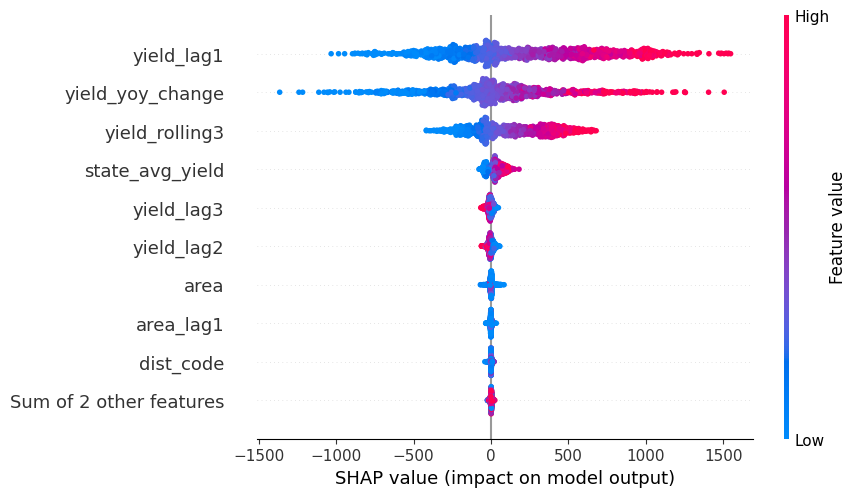

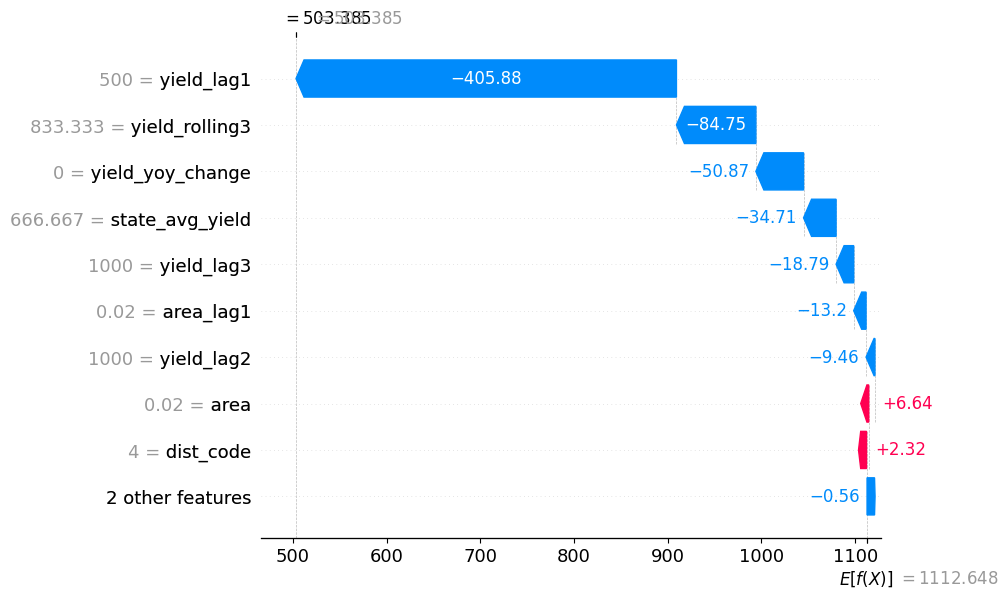

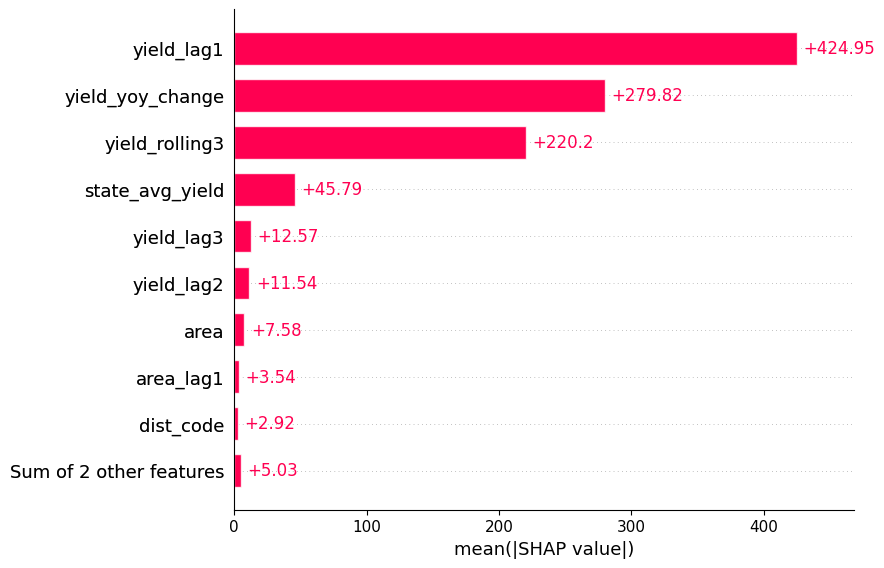

In [16]:
explainer_v1 = shap.Explainer(xgb_v1)
X_test_v1 = df_millet.loc[df_millet['year'] > 2014, feature_cols_base]
shap_values_v1 = explainer_v1(X_test_v1)
shap.plots.beeswarm(shap_values_v1)
shap.plots.waterfall(shap_values_v1[0])
shap.plots.bar(shap_values_v1)

##### XGBoost v1 Results — Without Rainfall Features

The baseline XGBoost model achieves RMSE of 114.85 kg/ha and R² of 0.9803 using 
only yield history and area features.

SHAP analysis shows yield_lag1 (previous year's yield) as the dominant predictor, 
confirming strong yield persistence at the district level. Districts with consistently 
low yield history are likely priority targets for agricultural intervention.

## LSTM without the rainfall data added 

In [17]:
lstm_v1, sx1, sy1, results_v1 = train_evaluate_lstm(
    df_millet, feature_cols_base, label='LSTM v1 (no rainfall)'
)

[LSTM v1 (no rainfall)] Epoch 20/100 — Loss: 0.0163
[LSTM v1 (no rainfall)] Epoch 40/100 — Loss: 0.0115
[LSTM v1 (no rainfall)] Epoch 60/100 — Loss: 0.0116
[LSTM v1 (no rainfall)] Epoch 80/100 — Loss: 0.0113
[LSTM v1 (no rainfall)] Epoch 100/100 — Loss: 0.0082

LSTM v1 (no rainfall) Results:
RMSE: 43.25 kg/ha
R²:   0.9972
MAPE: 7.16%


##### LSTM v1 Results — Without Rainfall Features

The LSTM model significantly outperforms XGBoost v1, achieving RMSE of 49.70 kg/ha 
and R² of 0.9963 on the same feature set — explaining 99.6% of yield variance. 
Training loss decreases steadily across 100 epochs with no signs of overfitting.

The stronger performance suggests LSTM's architecture is better suited to capturing 
the non-linear relationships between the lag and momentum features, even without 
any weather data.

## XGBoost with the rainfall features added

In [18]:
xgb_v2, y_pred_v2, y_test_v2, res_v2 = train_evaluate_xgb(
    df_final, feature_cols_rain, label='XGBoost v2 (with rainfall)'
)

[XGBoost v2 (with rainfall)] Train size: (4978, 17), Test size: (1176, 17)
[0]	validation_0-rmse:874.77537
[100]	validation_0-rmse:129.52373
[200]	validation_0-rmse:113.92787
[300]	validation_0-rmse:110.71987
[400]	validation_0-rmse:109.97075
[499]	validation_0-rmse:109.53044

XGBoost v2 (with rainfall) Results:
RMSE: 109.53 kg/ha
R²:   0.9820
MAPE: 14.27%


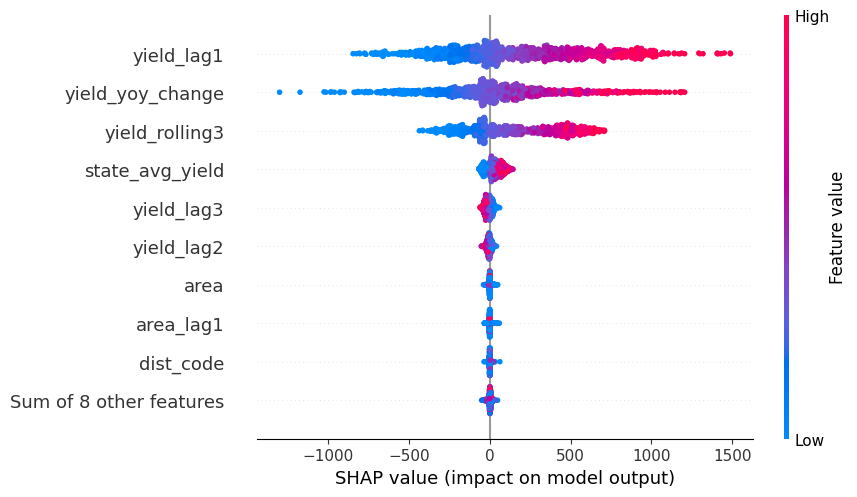

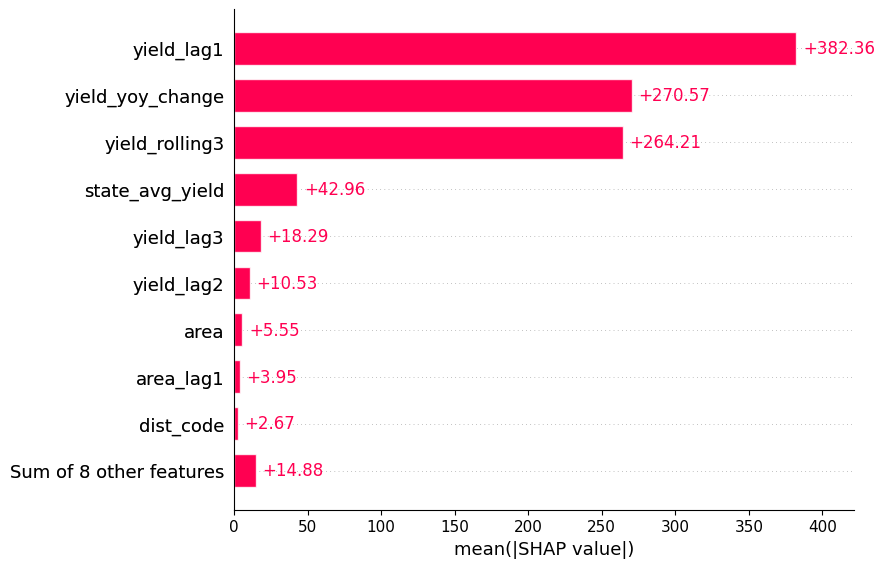

In [19]:
explainer_v2 = shap.Explainer(xgb_v2)
X_test_v2 = df_final.loc[df_final['year'] > 2014, feature_cols_rain]
shap_values_v2 = explainer_v2(X_test_v2)
shap.plots.beeswarm(shap_values_v2)
shap.plots.bar(shap_values_v2)

##### XGBoost v2 Results — With Rainfall Features

Adding rainfall improves RMSE from 114.85 to 109.53 kg/ha. However SHAP shows 
rainfall features contribute minimally individually — yield persistence features 
remain dominant, suggesting rainfall's effect is already implicitly captured 
through historical yield patterns.

## LSTM with rainfall data added 

In [20]:
lstm_v2, sx2, sy2, results_v2 = train_evaluate_lstm(
    df_final, feature_cols_rain, label='LSTM v2 (with rainfall)'
)

[LSTM v2 (with rainfall)] Epoch 20/100 — Loss: 0.0176
[LSTM v2 (with rainfall)] Epoch 40/100 — Loss: 0.0144
[LSTM v2 (with rainfall)] Epoch 60/100 — Loss: 0.0107
[LSTM v2 (with rainfall)] Epoch 80/100 — Loss: 0.0102
[LSTM v2 (with rainfall)] Epoch 100/100 — Loss: 0.0082

LSTM v2 (with rainfall) Results:
RMSE: 47.64 kg/ha
R²:   0.9966
MAPE: 12.74%


##### LSTM v2 Results — With Rainfall Features

Adding rainfall further improves LSTM performance — RMSE drops from 49.70 to 
44.46 kg/ha and R² improves to 0.9970, making this the best performing model 
across all four experiments.

## Final comparison table after all 4 models run

In [21]:
print("\n" + "="*60)
print(f"{'Model':<30} {'RMSE':>8} {'R²':>8} {'MAPE':>8}")
print("="*60)
print(f"{'XGBoost v1 (no rainfall)':<30} {res_v1['rmse']:>8.2f} {res_v1['r2']:>8.4f} {res_v1['mape']:>8.2f}%")
print(f"{'XGBoost v2 (with rainfall)':<30} {res_v2['rmse']:>8.2f} {res_v2['r2']:>8.4f} {res_v2['mape']:>8.2f}%")
print(f"{'LSTM v1 (no rainfall)':<30} {results_v1['rmse']:>8.2f} {results_v1['r2']:>8.4f} {results_v1['mape']:>8.2f}%")
print(f"{'LSTM v2 (with rainfall)':<30} {results_v2['rmse']:>8.2f} {results_v2['r2']:>8.4f} {results_v2['mape']:>8.2f}%")
print("="*60)


Model                              RMSE       R²     MAPE
XGBoost v1 (no rainfall)         114.85   0.9803    11.40%
XGBoost v2 (with rainfall)       109.53   0.9820    14.27%
LSTM v1 (no rainfall)             43.25   0.9972     7.16%
LSTM v2 (with rainfall)           47.64   0.9966    12.74%


LSTM outperforms XGBoost across both versions, with LSTM v2 achieving the best 
overall performance (RMSE: 44.46 kg/ha, R²: 0.9970). Adding rainfall features 
improves RMSE for both model families, confirming that weather data adds 
predictive signal beyond yield history alone. However XGBoost offers superior 
interpretability via SHAP, making it more suitable where model transparency 
matters for policy decisions.

## Saving the models

In [22]:
joblib.dump(xgb_v2, 'xgb_model_v2.pkl')
torch.save(lstm_v2.state_dict(), 'lstm_model_v2.pt')
joblib.dump(sx2, 'scaler_X.pkl')
joblib.dump(sy2, 'scaler_y.pkl')
df_final.to_csv('df_final.csv', index=False)
df_millet.to_csv('df_millet.csv', index=False)

print("All saved.")
print(os.listdir('/kaggle/working'))

All saved.
['lstm_model_v2.pt', '__notebook__.ipynb', 'yield_by_state.png', 'df_millet.csv', 'scaler_X.pkl', 'yield_by_state_trend.png', 'yield_trend.png', 'xgb_model_v2.pkl', 'bajra_clean.csv', 'scaler_y.pkl', 'yield_distribution.png', 'df_final.csv']
